
# Clustering Algorithms

Unsupervised learning focuses on finding patterns in data without labeled outputs. Clustering is a key unsupervised learning technique that groups similar observations together based on their features. It is exploratory in nature, meaning the results can vary significantly depending on the algorithm, distance metric used, and parameters set.

Common clustering algorithms include:

-   **k-Means**: Partitions data into $k$ clusters by minimizing the variance within each cluster.
-   **Hierarchical Clustering**: Builds a hierarchy of clusters, either agglomerative (bottom-up) or divisive (top-down).
-   **DBSCAN**: Density-Based Spatial Clustering of Applications with Noise, which finds clusters of varying shape and density.
-   **Gaussian Mixture Models (GMM)**: Assumes data is generated from a mixture of several Gaussian distributions and uses the Expectation-Maximization algorithm to estimate parameters.

## Advantages and Disadvantages

-   **Advantages**:
    -   Can discover hidden patterns and structures in data.
    -   Useful for exploratory data analysis and feature engineering.
    -   Can handle large datasets without the need for labeled data.
-   **Disadvantages**:
    -   Results can be difficult to interpret (no "ground truth").
    -   No guarantee of finding meaningful patterns; results can be sensitive to the choice of algorithm and parameters.
    -   Evaluation of clustering results is challenging.

## K-Means

K-Means is a popular clustering algorithm that partitions data into $k$ clusters by minimizing the variance within each cluster.

### The Algorithm

Mathematically, K-Means aims to minimize the within-cluster sum of squares (WCSS), formally: $$ \sum_{i=1}^{k} \sum_{x \in C_i} ||x - \mu_i||^2 $$ where $\mu_i$ is the centroid of cluster $C_i$.

The steps are:

1.  Initialize $k$ centroids randomly from the data points.
2.  Assign each data point to the nearest centroid based on a distance metric (commonly Euclidean distance).
3.  Update the centroids by calculating the mean of all points assigned to each cluster.
4.  Repeat steps 2 and 3 until convergence (i.e., centroids do not change significantly).

### Advantages and Disadvantages

-   **Advantages**:
    -   Simple and efficient for large datasets.
    -   Works well when clusters are spherical and of similar size.
-   **Disadvantages**:
    -   Requires specifying the number of clusters ($k$) beforehand.
    -   Sensitive to outliers and noise.
    -   Assumes clusters are spherical and equally sized, which may not hold in practice.

### Example

To illustrate the concepts, we will use the Iris dataset. We will use the **Elbow Method** to determine the optimal number of clusters, apply PCA for dimensionality reduction, and then perform K-Means.

-   Load the Iris dataset

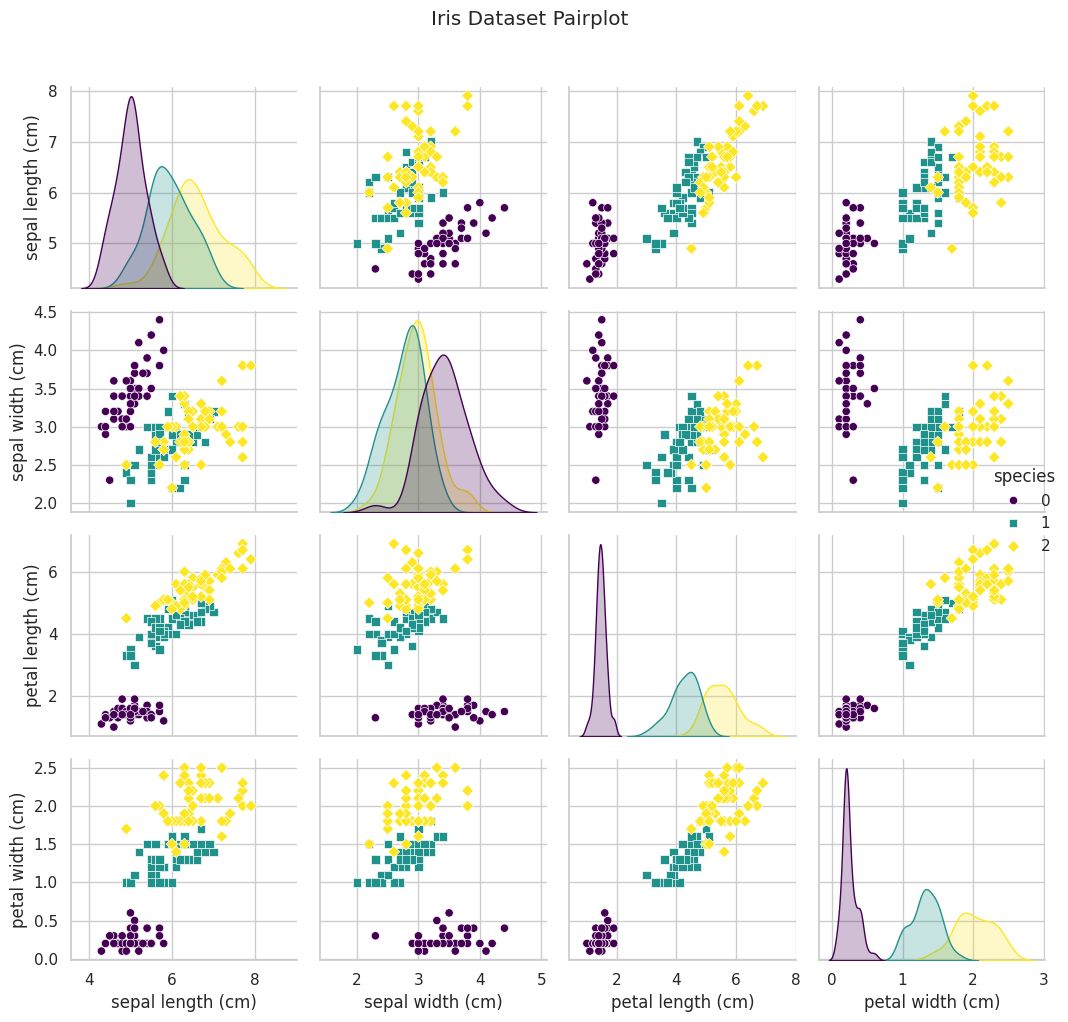

In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_iris

sns.set_theme(style="whitegrid")

# Load the Iris dataset
iris = load_iris(as_frame=True)
X = iris.data
y = iris.target  # We will NOT use this for training, only for validation later

df = pd.concat([X, pd.Series(y, name='species')], axis=1)
sns.pairplot(df, hue='species', palette='viridis', markers=["o", "s", "D"])
plt.suptitle('Iris Dataset Pairplot', y=1.02)
plt.tight_layout()
plt.show()

-   Preprocess the data and Apply PCA

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Standardize the data (Crucial for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA to reduce to 2 dimensions for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

-   Determine optimal k using the Elbow Method

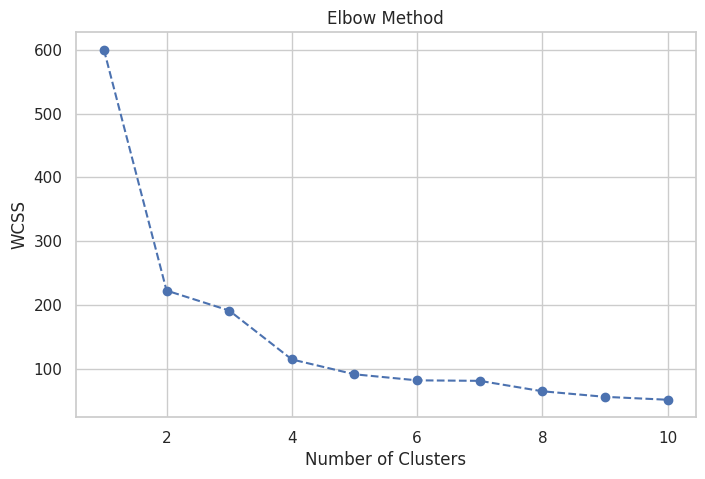

In [3]:
from sklearn.cluster import KMeans

wcss = []
range_k = range(1, 11)
for i in range_k:
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range_k, wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

-   Apply K-Means clustering (with k=3)

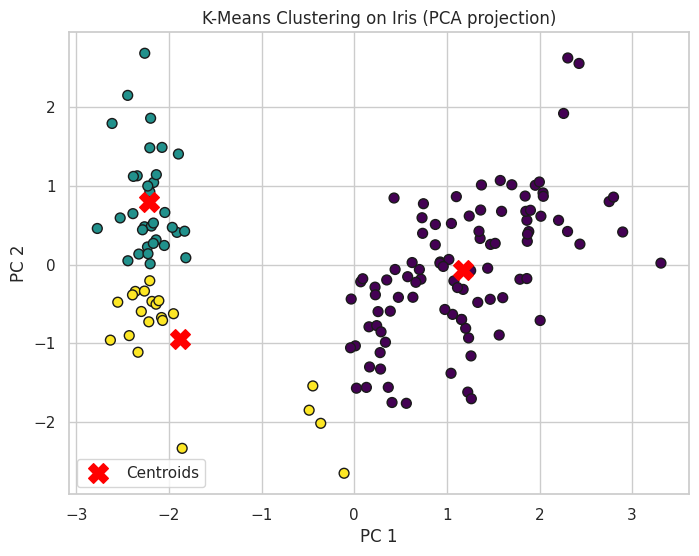

In [4]:
# Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
y_kmeans = kmeans.fit_predict(X_scaled)

# Plot the results on PCA-reduced data
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans, cmap='viridis', edgecolor='k', s=50)

# Transform centroids to PCA space for visualization
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            s=200, c='red', marker='X', label='Centroids')

plt.title('K-Means Clustering on Iris (PCA projection)')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend()
plt.show()

-   Evaluate the clustering results

In [5]:
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Calculate the silhouette score
silhouette_avg = silhouette_score(X_scaled, y_kmeans)
print(f'Silhouette Score: {silhouette_avg:.2f}')

# Calculate the adjusted Rand Index (ARI) to compare with true labels
ari = adjusted_rand_score(y, y_kmeans)
print(f'Adjusted Rand Index: {ari:.2f}')

Silhouette Score: 0.48
Adjusted Rand Index: 0.43


## Hierarchical Clustering

Hierarchical clustering builds a hierarchy of clusters. It does not require specifying the number of clusters in advance and produces a dendrogram.

### Advantages and Disadvantages

-   **Advantages**:
    -   No need to predefine the number of clusters.
    -   Visual hierarchy via dendrograms helps interpret data relationships.
-   **Disadvantages**:
    -   Computationally expensive for large datasets ($O(n^3)$ or $O(n^2)$).
    -   Sensitive to noise and outliers.

### Example: Dendrogram

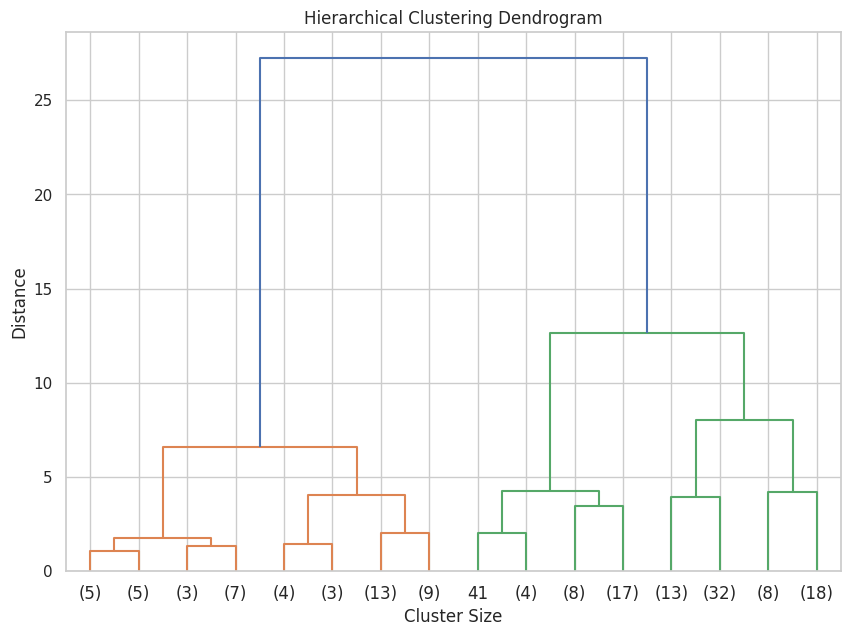

In [6]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Compute linkage matrix using Ward's method
# Ward minimizes variance within clusters
linkage_matrix = linkage(X_scaled, method='ward')

# Plot the dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linkage_matrix, truncate_mode="level", p=3)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Cluster Size')
plt.ylabel('Distance')
plt.show()

-   Apply Agglomerative Clustering

Silhouette Score: 0.45
Adjusted Rand Index: 0.62


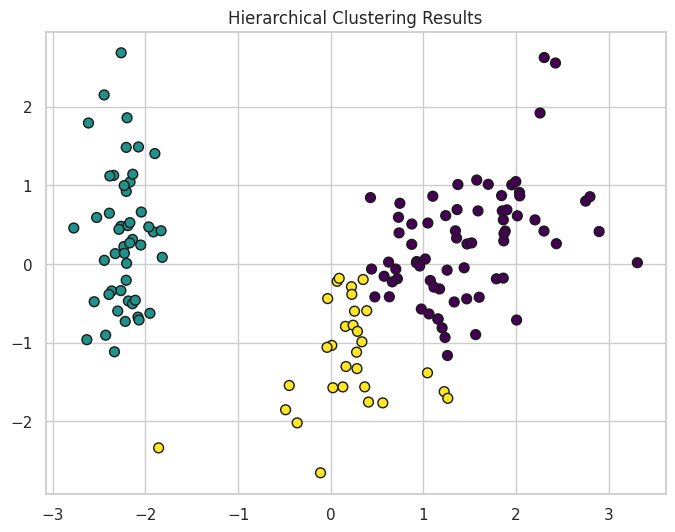

In [7]:
# Perform hierarchical clustering
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
y_hc = hc.fit_predict(X_scaled)

# Evaluate
print(f'Silhouette Score: {silhouette_score(X_scaled, y_hc):.2f}')
print(f'Adjusted Rand Index: {adjusted_rand_score(y, y_hc):.2f}')

# Visualize
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_hc, cmap='viridis', edgecolor='k', s=50)
plt.title('Hierarchical Clustering Results')
plt.show()

## DBSCAN

Density-Based Spatial Clustering of Applications with Noise (DBSCAN) groups points that are close to each other based on a distance measurement (epsilon) and a minimum number of points (min\_samples). It marks points in low-density regions as outliers.

### Advantages and Disadvantages

-   **Advantages**:
    -   Can find arbitrarily shaped clusters (e.g., crescents).
    -   Robust to outliers.
    -   Does not require specifying $k$.
-   **Disadvantages**:
    -   Difficult to find optimal \`eps\` and \`min\_samples\` if density varies across clusters.
    -   Struggles with high-dimensional data (curse of dimensionality).

### Example

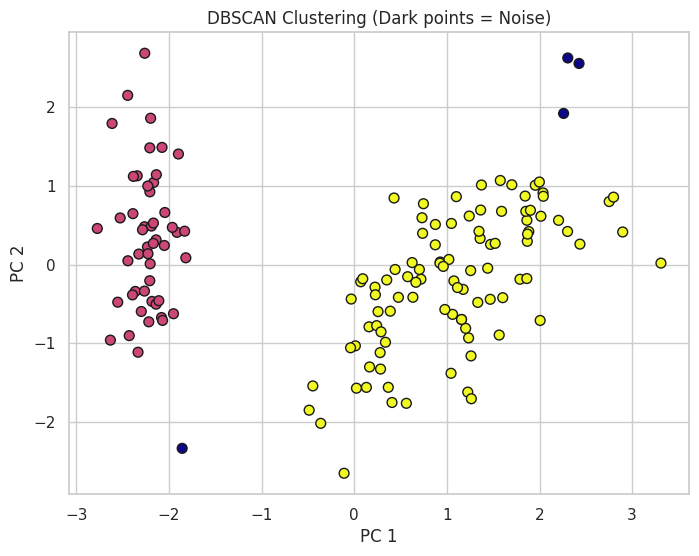

In [8]:
from sklearn.cluster import DBSCAN

# Apply DBSCAN
# eps: max distance between samples
# min_samples: min samples in neighborhood to be a core point
dbscan = DBSCAN(eps=0.8, min_samples=5)
y_dbscan = dbscan.fit_predict(X_scaled)

# Visualize (Label -1 indicates noise)
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_dbscan, cmap='plasma', edgecolor='k', s=50)
plt.title('DBSCAN Clustering (Dark points = Noise)')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.show()

## Gaussian Mixture Models (GMM)

GMM assumes that the data is generated from a mixture of a finite number of Gaussian distributions with unknown parameters. Unlike K-Means (hard clustering), GMM provides "soft clustering" where each point belongs to a cluster with a certain probability.

### Example

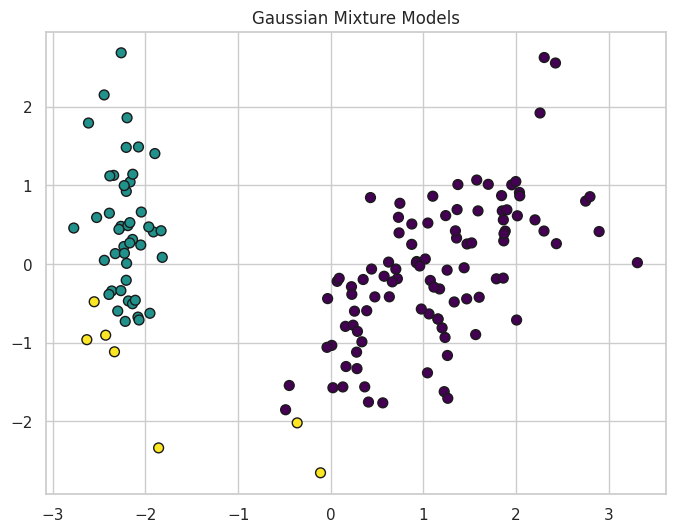

Cluster Probabilities for first 5 samples:
 [[2.74503381e-011 1.00000000e+000 0.00000000e+000]
 [1.16033052e-007 9.99999884e-001 0.00000000e+000]
 [9.72921434e-009 9.99999990e-001 5.88168010e-278]
 [2.02193473e-007 9.99999798e-001 3.33173699e-141]
 [9.67775891e-012 1.00000000e+000 0.00000000e+000]]


In [9]:
from sklearn.mixture import GaussianMixture

# Apply GMM
gmm = GaussianMixture(n_components=3, random_state=42)
gmm.fit(X_scaled)
y_gmm = gmm.predict(X_scaled)

# Visualize
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_gmm, cmap='viridis', edgecolor='k', s=50)
plt.title('Gaussian Mixture Models')
plt.show()

# Check probabilities for the first 5 samples
probs = gmm.predict_proba(X_scaled)[:5]
print("Cluster Probabilities for first 5 samples:\n", probs)

## Exercises

Use K-Means and Hierarchical Clustering on the Breast Cancer Wisconsin dataset.

### Load and Preprocess

In [10]:
from sklearn.datasets import load_breast_cancer

# Load the Breast Cancer Wisconsin dataset
data = load_breast_cancer()
X_bc = data.data
y_bc = data.target

# Standardize the data
scaler_bc = StandardScaler()
X_bc_scaled = scaler_bc.fit_transform(X_bc)

# Apply PCA to reduce to 2 dimensions for visualization
pca_bc = PCA(n_components=2, random_state=42)
X_bc_pca = pca_bc.fit_transform(X_bc_scaled)

### K-Means

In [11]:
# Apply K-Means clustering
kmeans_bc = KMeans(n_clusters=2, random_state=42, n_init='auto')
y_kmeans_bc = kmeans_bc.fit_predict(X_bc_scaled)

# Evaluate
sil_bc = silhouette_score(X_bc_scaled, y_kmeans_bc)
ari_bc = adjusted_rand_score(y_bc, y_kmeans_bc)
print(f'K-Means -- Silhouette: {sil_bc:.2f}, ARI: {ari_bc:.2f}')

K-Means -- Silhouette: 0.34, ARI: 0.68


### Hierarchical Clustering

In [12]:
# Perform hierarchical clustering
cls_bc = AgglomerativeClustering(linkage='ward', n_clusters=2)
y_hc_bc = cls_bc.fit_predict(X_bc_scaled)

# Evaluate
sil_hc = silhouette_score(X_bc_scaled, y_hc_bc)
ari_hc = adjusted_rand_score(y_bc, y_hc_bc)
print(f'Hierarchical -- Silhouette: {sil_hc:.2f}, ARI: {ari_hc:.2f}')

Hierarchical -- Silhouette: 0.34, ARI: 0.58


### Comparison Visualization

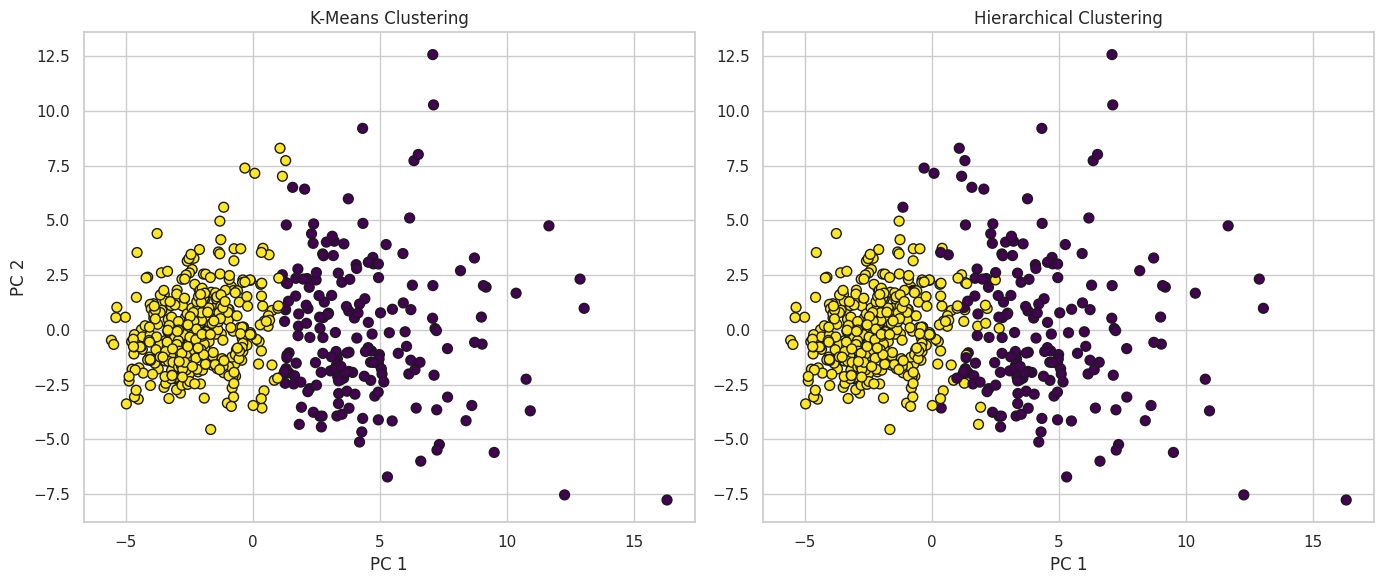

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# K-Means Plot
axes[0].scatter(X_bc_pca[:, 0], X_bc_pca[:, 1], c=y_kmeans_bc, cmap='viridis', edgecolor='k', s=50)
axes[0].set_title('K-Means Clustering')
axes[0].set_xlabel('PC 1')
axes[0].set_ylabel('PC 2')

# Hierarchical Plot
axes[1].scatter(X_bc_pca[:, 0], X_bc_pca[:, 1], c=y_hc_bc, cmap='viridis', edgecolor='k', s=50)
axes[1].set_title('Hierarchical Clustering')
axes[1].set_xlabel('PC 1')

plt.tight_layout()
plt.show()